In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.pipelines.hybrid_resnet50_pipeline import HybridResNet50_pipeline

import pandas as pd
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor


Use weighted cross entropy: False

EXPERIMENTO K-FOLD: hybrid_resnet50_binario
Total patchs: 5290
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 3635 patchs (214 cálculos)
  Val:   627 patchs (35 cálculos)
  Test:  1028 patchs (62 cálculos)
Device: cuda
Trainable parameters: 535,810
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4938 acc=0.7605 f1=0.7605 | val: loss=0.4186 acc=0.8054 f1=0.8020 | lr=1.00e-04 | 11.1s
Epoch   2/30 | train: loss=0.4351 acc=0.7930 f1=0.7930 | val: loss=0.4756 acc=0.7592 f1=0.7495 | lr=1.00e-04 | 10.8s
Epoch   3/30 | train: loss=0.4161 acc=0.8100 f1=0.8100 | val: loss=0.4610 acc=0.7735 f1=0.7670 | lr=1.00e-04 | 10.4s
Epoch   4/30 | train: loss=0.4063 acc=0.8139 f1=0.8139 | val: loss=0.4800 acc=0.7719 f1=0.7600 | lr=1.00e-04 | 10.4s
Epoch   5/30 | train: loss=0.3910 acc=0.8318 f1=0.8318 | val: loss=0.4697 acc=0.7879 f1=0.7786 | lr=1.00e-05 | 10.4s
Epoch   6/30 | train: loss=0.3739 acc=0.8318 f1=0.8318 | va

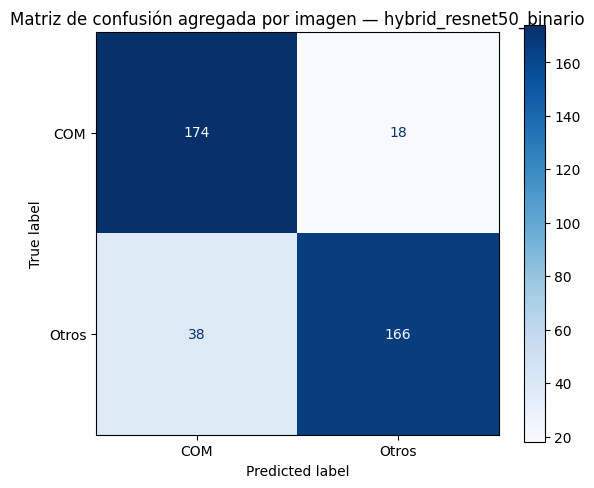

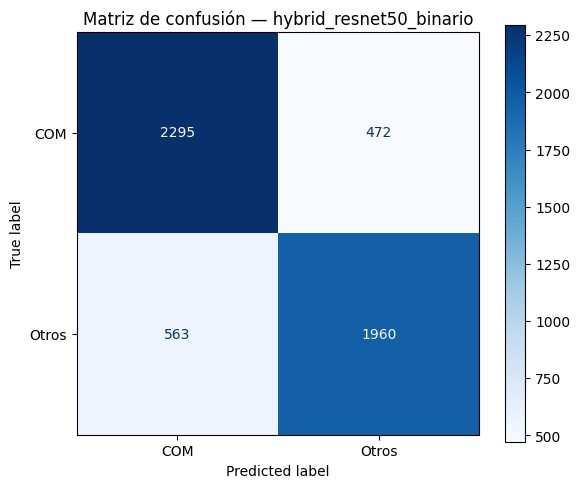


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8054 ± 0.0314
  auc_weighted: 0.8948 ± 0.0184
  f1_weighted: 0.8048 ± 0.0329
  precision_weighted: 0.8133 ± 0.0280
  recall_weighted: 0.8054 ± 0.0314


{'name': 'hybrid_resnet50_binario',
 'fold_results': [{'accuracy': 0.8258754863813229,
   'precision_weighted': 0.8316818153997543,
   'recall_weighted': 0.8258754863813229,
   'f1_weighted': 0.8256574069019138,
   'auc_weighted': 0.9060415916285948,
   'per_class': {'precision': [0.8771186440677966, 0.7823741007194245],
    'recall': [0.7738317757009345, 0.8823529411764706],
    'f1': [0.8222442899702085, 0.8293612964728313],
    'class_names': ['COM', 'Otros']},
   'confusion_matrix': [[414, 121], [58, 435]],
   'classification_report': {'COM': {'precision': 0.8771186440677966,
     'recall': 0.7738317757009345,
     'f1-score': 0.8222442899702085,
     'support': 535.0},
    'Otros': {'precision': 0.7823741007194245,
     'recall': 0.8823529411764706,
     'f1-score': 0.8293612964728313,
     'support': 493.0},
    'accuracy': 0.8258754863813229,
    'macro avg': {'precision': 0.8297463723936105,
     'recall': 0.8280923584387025,
     'f1-score': 0.82580279322152,
     'support': 1

In [3]:
all_results = []
patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")
task_name= "binario"
task_config= TASKS[task_name]
patches_task = assign_task_labels(patches_df_full, task_config)
config = {
            "name": f"hybrid_resnet50_{task_name}",
            "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_patches/resnet50_{task_name}",
            "class_names": task_config["class_names"],
            "batch_size": 8
        }
        
lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)
hybridresnet50_model= HybridResNet50_pipeline(df = patches_task, case= Case.PATCH, extractor= extractor)
hybridresnet50_model.run_model(config, show_fold_metrics= True)



EXPERIMENTO K-FOLD: hybrid_resnet50_binario
Total patchs: 5290
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 3635 patchs (214 cálculos)
  Val:   627 patchs (35 cálculos)
  Test:  1028 patchs (62 cálculos)
Device: cuda
Trainable parameters: 535,810
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4709 acc=0.7734 f1=0.7734 | val: loss=0.4456 acc=0.7783 f1=0.7701 | lr=1.00e-04 | 9.2s
Epoch   2/30 | train: loss=0.4050 acc=0.8186 f1=0.8186 | val: loss=0.4405 acc=0.7959 f1=0.7868 | lr=1.00e-04 | 8.8s
Epoch   3/30 | train: loss=0.3770 acc=0.8331 f1=0.8331 | val: loss=0.4295 acc=0.8006 f1=0.7929 | lr=1.00e-04 | 8.8s
Epoch   4/30 | train: loss=0.3551 acc=0.8422 f1=0.8422 | val: loss=0.4778 acc=0.7735 f1=0.7578 | lr=1.00e-04 | 8.8s
Epoch   5/30 | train: loss=0.3366 acc=0.8475 f1=0.8475 | val: loss=0.4707 acc=0.7943 f1=0.7823 | lr=1.00e-04 | 8.8s
Epoch   6/30 | train: loss=0.3325 acc=0.8524 f1=0.8524 | val: loss=0.4396 acc=0.8118 f1=0.8047 | l

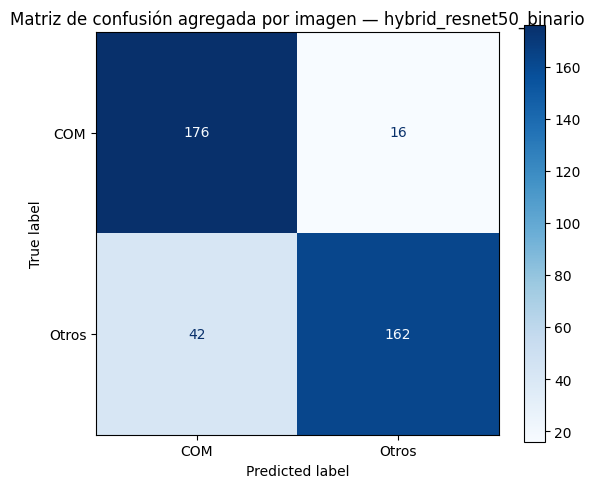

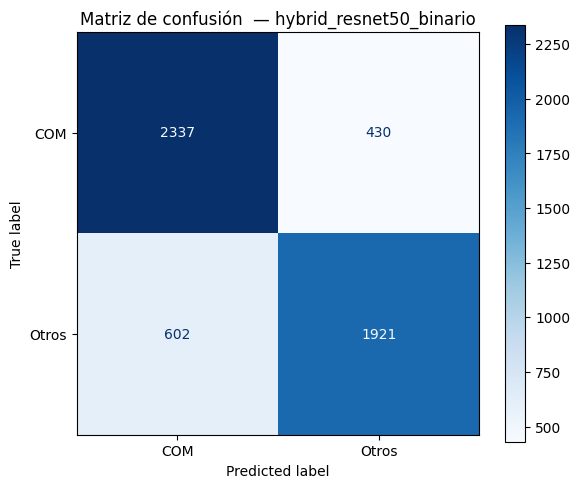


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8062 ± 0.0327
  auc_weighted: 0.8965 ± 0.0135
  f1_weighted: 0.8051 ± 0.0349
  npv_weighted: 0.8062 ± 0.0208
  precision_weighted: 0.8179 ± 0.0255
  recall_weighted: 0.8062 ± 0.0327
  specificity_weighted: 0.8098 ± 0.0373


In [6]:
patches_df_augmented = pd.read_csv(f"experiments/patches_{PATCH_SIZE}/multiclass_metadata_balanced.csv")
patches_task = assign_task_labels(patches_df_augmented, task_config)
config = {
            "name": f"hybrid_resnet50_{task_name}",
            "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_patches/resnet50_{task_name}",
            "class_names": task_config["class_names"],
            "batch_size": 16
        }
        
hybridresnet50_model= HybridResNet50_pipeline(df = patches_task, case= Case.PATCH, extractor= extractor)

hybridresnet50_model.run_model(config, show_fold_metrics= True)
